In [9]:
#caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('/Users/marco/Documents/Biometry/DLL/DLLM_Project/DLLM_Project/data/raw/heloc_dataset.csv')


Distribuzione dei valori incerti (-7, -8, -9) per colonna:

                                    Valore -7  Valore -8  Valore -9
RiskPerformance                             0          0          0
ExternalRiskEstimate                        0          0        598
MSinceOldestTradeOpen                       0        239        588
MSinceMostRecentTradeOpen                   0          0        588
AverageMInFile                              0          0        588
NumSatisfactoryTrades                       0          0        588
NumTrades60Ever2DerogPubRec                 0          0        588
NumTrades90Ever2DerogPubRec                 0          0        588
PercentTradesNeverDelq                      0          0        588
MSinceMostRecentDelq                     4664        176        588
MaxDelq2PublicRecLast12M                    0          0        588
MaxDelqEver                                 0          0        588
NumTotalTrades                              0          0

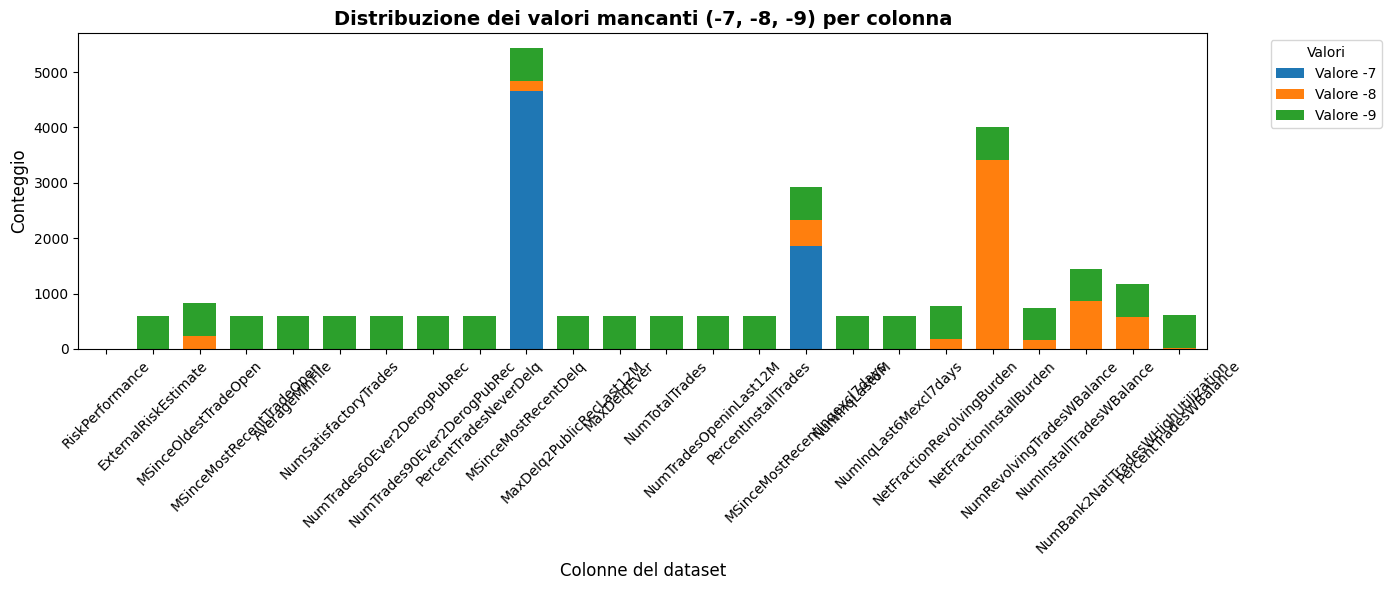

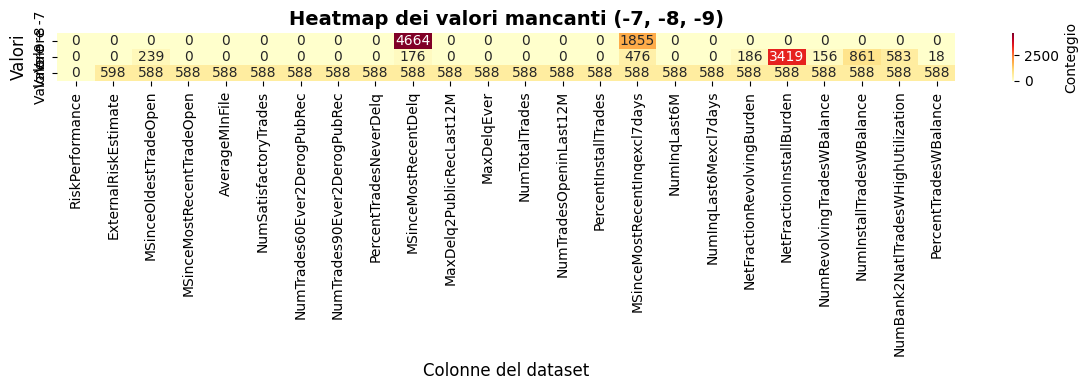

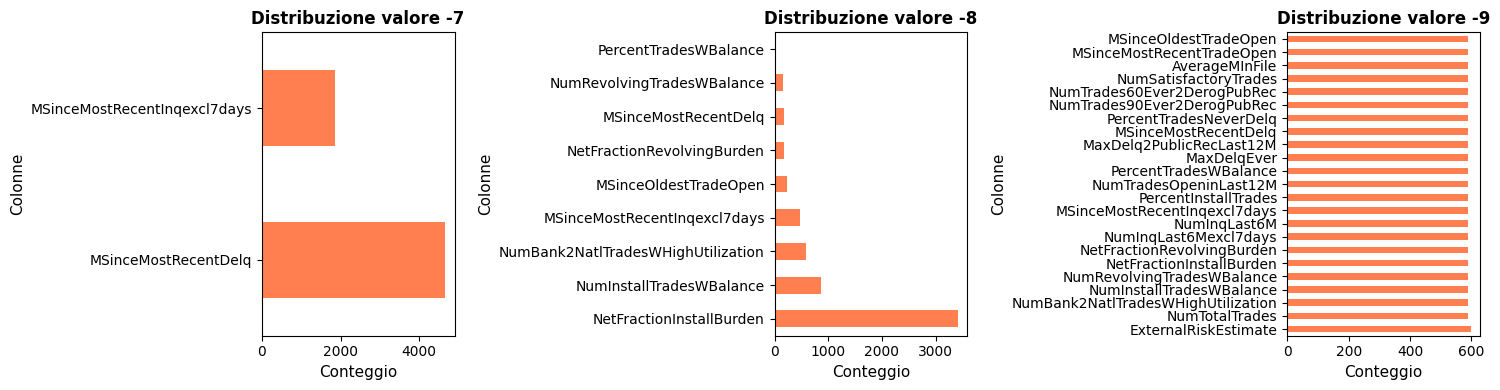

In [10]:
#Analisi e visualizzazione dei valori mancanti -7, -8, -9

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Valori mancanti
uncertain_values = [-7, -8, -9]

# Conteggio dei valori per colonna
print("Distribuzione dei valori incerti (-7, -8, -9) per colonna:\n")

# Creazione di un dataframe per contare i valori
missing_count_by_col = pd.DataFrame()

for val in uncertain_values:
    missing_count_by_col[f'Valore {val}'] = (df == val).sum()

print(missing_count_by_col)
print(f"\nTotale valori incerti: {missing_count_by_col.sum().sum():,}")

# Visualizzazione 1: Stacked Bar Chart per colonna
fig, ax = plt.subplots(figsize=(14, 6))
missing_count_by_col.plot(kind='bar', stacked=True, ax=ax, width=0.7)
ax.set_title('Distribuzione dei valori mancanti (-7, -8, -9) per colonna', fontsize=14, fontweight='bold')
ax.set_xlabel('Colonne del dataset', fontsize=12)
ax.set_ylabel('Conteggio', fontsize=12)
ax.legend(title='Valori', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Visualizzazione 2: Heatmap
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(missing_count_by_col.T, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Conteggio'}, ax=ax)
ax.set_title('Heatmap dei valori mancanti (-7, -8, -9)', fontsize=14, fontweight='bold')
ax.set_xlabel('Colonne del dataset', fontsize=12)
ax.set_ylabel('Valori', fontsize=12)
plt.tight_layout()
plt.show()

# Visualizzazione 3: Distribuzione per valore
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, val in enumerate(uncertain_values):
    val_count = (df == val).sum().sort_values(ascending=False)
    val_count = val_count[val_count > 0]  # Filtra solo le colonne con questo valore
    
    val_count.plot(kind='barh', ax=axes[idx], color='coral')
    axes[idx].set_title(f'Distribuzione valore {val}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Conteggio', fontsize=11)
    axes[idx].set_ylabel('Colonne', fontsize=11)
    
    if len(val_count) == 0:
        axes[idx].text(0.5, 0.5, f'Nessun valore {val} trovato', 
                      ha='center', va='center', transform=axes[idx].transAxes)

plt.tight_layout()
plt.show()


Numero di righe con tutti i valori '-9': 0
Percentuale del dataset: 0.00%

Numero di righe con almeno un valore '-9': 598
Percentuale del dataset: 5.72%


Distribuzione del valore '-9' per colonna:
ExternalRiskEstimate                  598
NumTradesOpeninLast12M                588
NumBank2NatlTradesWHighUtilization    588
NumInstallTradesWBalance              588
NumRevolvingTradesWBalance            588
NetFractionInstallBurden              588
NetFractionRevolvingBurden            588
NumInqLast6Mexcl7days                 588
NumInqLast6M                          588
MSinceMostRecentInqexcl7days          588
PercentInstallTrades                  588
NumTotalTrades                        588
MSinceOldestTradeOpen                 588
MaxDelqEver                           588
MaxDelq2PublicRecLast12M              588
MSinceMostRecentDelq                  588
PercentTradesNeverDelq                588
NumTrades90Ever2DerogPubRec           588
NumTrades60Ever2DerogPubRec           588
Num

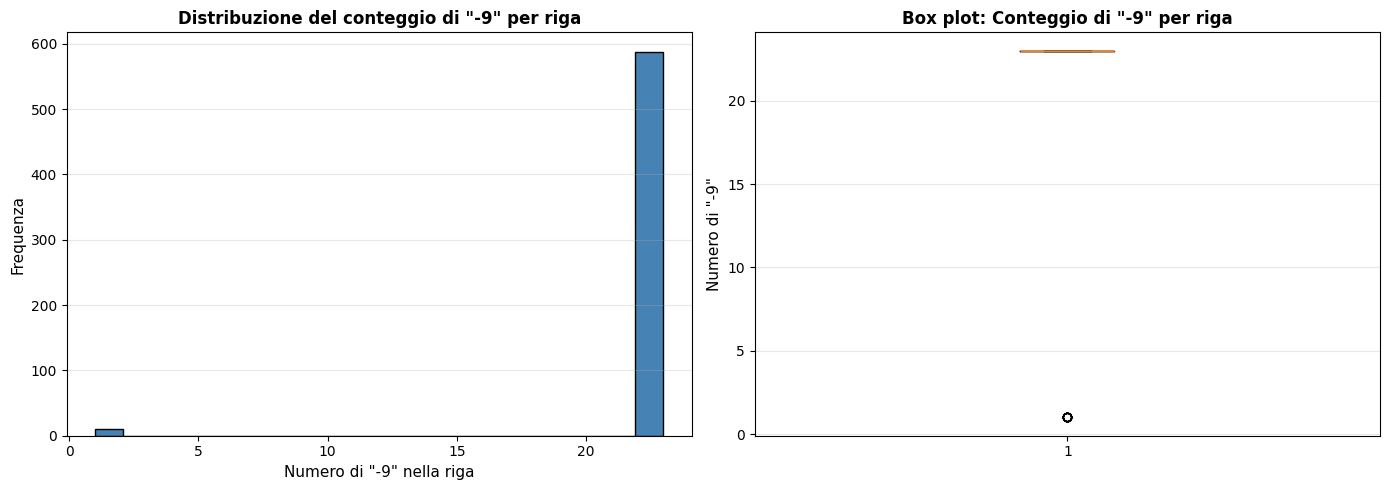

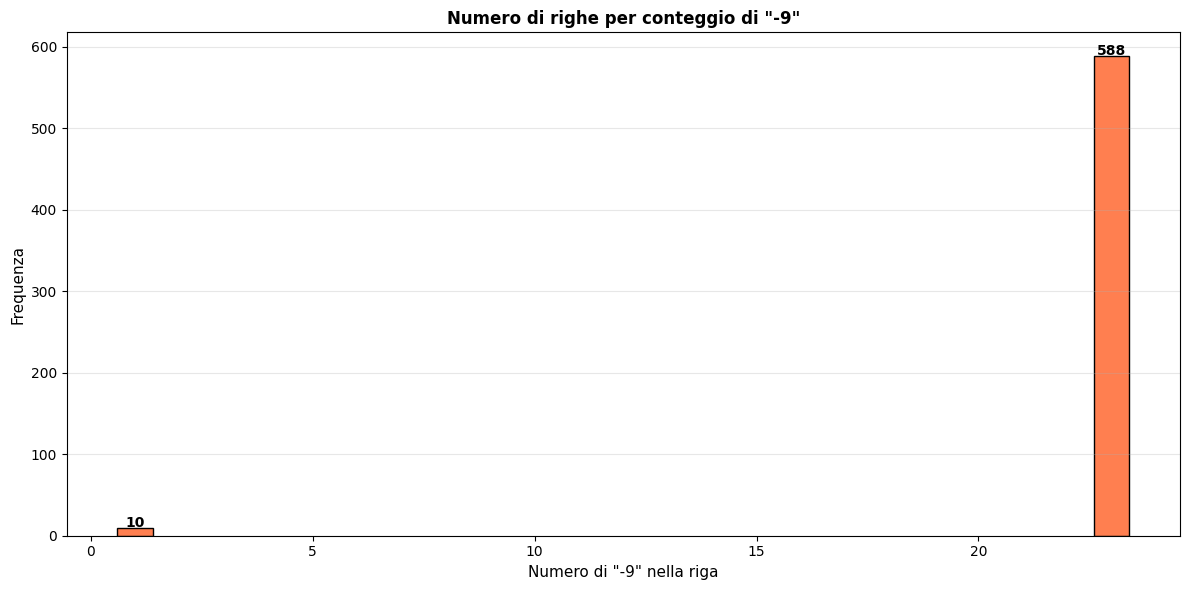

In [11]:
#Analisi approfondita delle righe con tutti i valori "-9"

# Identificare le righe dove tutti i valori sono -9
rows_all_minus_9 = (df == -9).all(axis=1)
df_all_minus_9 = df[rows_all_minus_9]

print(f"\nNumero di righe con tutti i valori '-9': {len(df_all_minus_9)}")
print(f"Percentuale del dataset: {(len(df_all_minus_9) / len(df) * 100):.2f}%")

# Identificare le righe dove almeno un valore è -9
rows_any_minus_9 = (df == -9).any(axis=1)
df_any_minus_9 = df[rows_any_minus_9]

print(f"\nNumero di righe con almeno un valore '-9': {len(df_any_minus_9)}")
print(f"Percentuale del dataset: {(len(df_any_minus_9) / len(df) * 100):.2f}%")

# Conteggio di -9 per colonna
minus_9_per_col = (df == -9).sum()
print(f"\n\nDistribuzione del valore '-9' per colonna:")
print(minus_9_per_col[minus_9_per_col > 0].sort_values(ascending=False))

# Statistiche per righe con -9
print(f"\n\nStatistiche per righe con almeno un valore '-9':")
minus_9_count_per_row = (df_any_minus_9 == -9).sum(axis=1)
print(f"  Media di '-9' per riga: {minus_9_count_per_row.mean():.2f}")
print(f"  Minimo: {minus_9_count_per_row.min()}")
print(f"  Massimo: {minus_9_count_per_row.max()}")
print(f"  Mediana: {minus_9_count_per_row.median():.2f}")

# Visualizzazione: Distribuzione del conteggio di -9 per riga
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(minus_9_count_per_row, bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribuzione del conteggio di "-9" per riga', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Numero di "-9" nella riga', fontsize=11)
axes[0].set_ylabel('Frequenza', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Box plot
axes[1].boxplot(minus_9_count_per_row, vert=True)
axes[1].set_title('Box plot: Conteggio di "-9" per riga', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Numero di "-9"', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Visualizzazione: Percentuale di righe per conteggio di -9
value_counts = minus_9_count_per_row.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(value_counts.index, value_counts.values, color='coral', edgecolor='black')
ax.set_title('Numero di righe per conteggio di "-9"', fontsize=12, fontweight='bold')
ax.set_xlabel('Numero di "-9" nella riga', fontsize=11)
ax.set_ylabel('Frequenza', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Aggiungi i valori sopra le barre
for i, v in enumerate(value_counts.values):
    ax.text(value_counts.index[i], v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



Righe con almeno un valore '-9': 598
Righe originali: 10,459
Righe dopo rimozione: 9,861
Righe eliminate: 598
Percentuale rimossa: 5.72%


Verifica post-rimozione - Distribuzione '-9' per colonna:
Nessun valore '-9' rimasto nel dataset


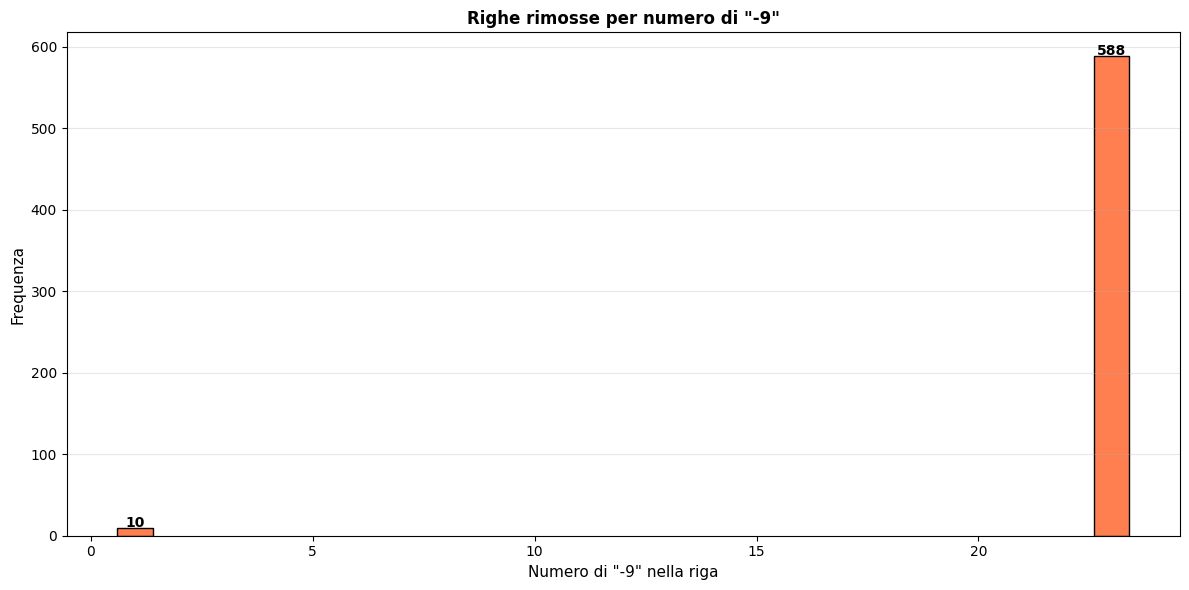

In [12]:
#Rimozione di tutte le righe con valori "-9" mancanti

# Identificare tutte le righe che hanno almeno un valore "-9"
rows_with_minus_9 = (df == -9).any(axis=1)

print(f"\nRighe con almeno un valore '-9': {rows_with_minus_9.sum()}")
print(f"Righe originali: {len(df):,}")

# Crea dataset pulito rimuovendo tutte le righe con -9
df_cleaned = df[~rows_with_minus_9].copy()
print(f"Righe dopo rimozione: {len(df_cleaned):,}")
print(f"Righe eliminate: {rows_with_minus_9.sum()}")
print(f"Percentuale rimossa: {(rows_with_minus_9.sum() / len(df) * 100):.2f}%")

# Verifica: mostra i "-9" rimanenti (dovrebbe essere 0)
print(f"\n\nVerifica post-rimozione - Distribuzione '-9' per colonna:")
remaining_minus_9 = (df_cleaned == -9).sum()
if (remaining_minus_9 > 0).any():
    print(remaining_minus_9[remaining_minus_9 > 0].sort_values(ascending=False))
else:
    print("Nessun valore '-9' rimasto nel dataset")

# Visualizzazione: Righe rimosse per conteggio di -9
fig, ax = plt.subplots(figsize=(12, 6))

minus_9_count_original = (df == -9).sum(axis=1)
value_counts = minus_9_count_original[minus_9_count_original > 0].value_counts().sort_index()

ax.bar(value_counts.index, value_counts.values, color='coral', edgecolor='black')
ax.set_title('Righe rimosse per numero di "-9"', fontsize=12, fontweight='bold')
ax.set_xlabel('Numero di "-9" nella riga', fontsize=11)
ax.set_ylabel('Frequenza', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Aggiungi i valori sopra le barre
for i, v in enumerate(value_counts.values):
    ax.text(value_counts.index[i], v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


#salvataggio
df_cleaned.to_csv('/Users/marco/Documents/Biometry/DLL/DLLM_Project/DLLM_Project/data/processed/heloc_dataset_no9ML.csv', index=False)



Colonne con almeno un valore '-7': 2

Distribuzione di '-7' per colonna:
MSinceMostRecentDelq            4658
MSinceMostRecentInqexcl7days    1853
dtype: int64


Righe con almeno un valore '-7': 5,681
Percentuale del dataset: 57.61%
Righe senza alcun '-7': 4,180


Statistiche per righe con almeno un valore '-7':
  Media di '-7' per riga (escludendo zeri): 1.15
  Minimo: 1
  Massimo: 2
  Mediana: 1.00


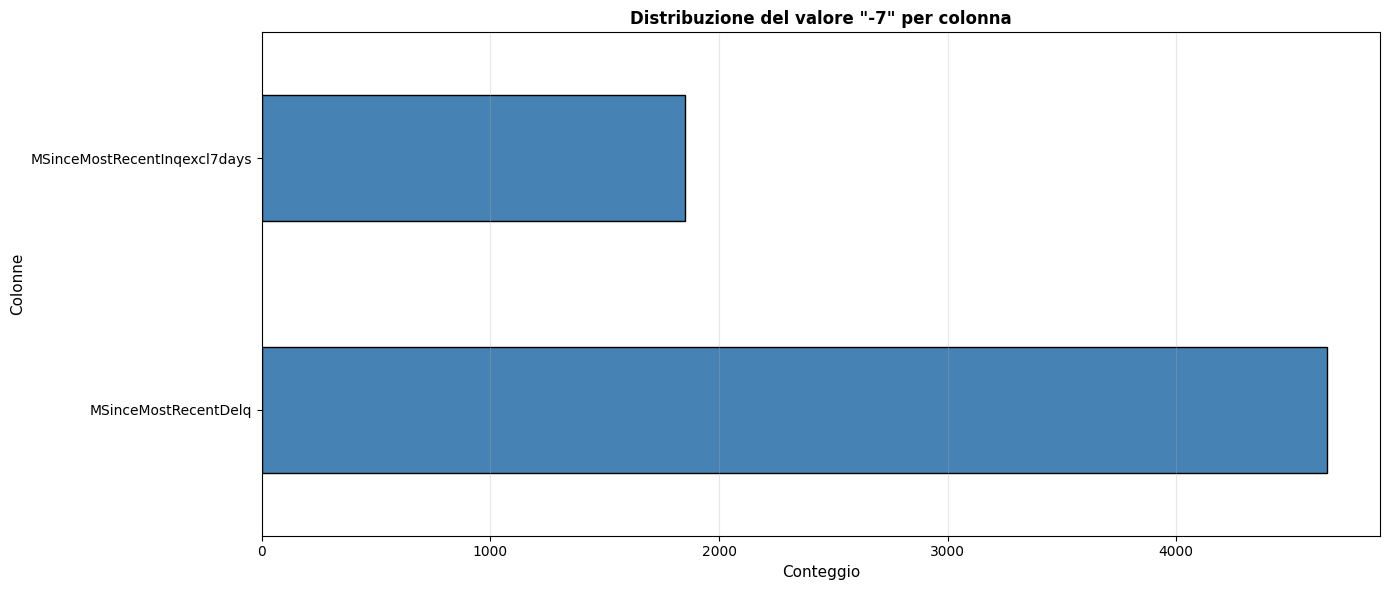

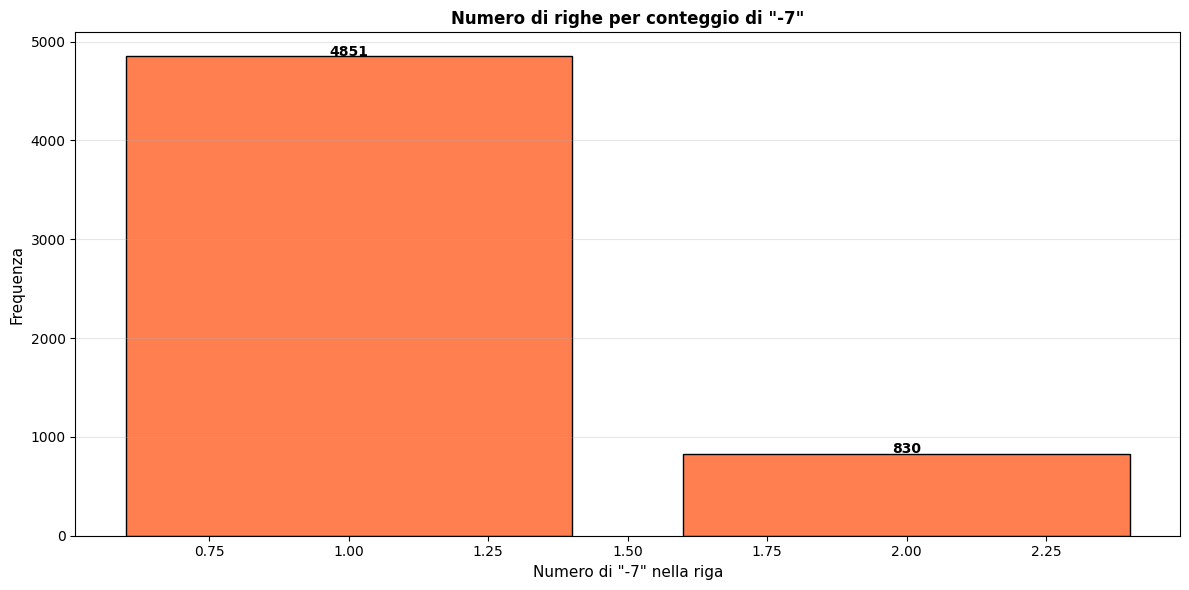

In [13]:
#Analisi del valore "-7" su heloc_dataset_no9.csv

# Caricamento del dataset senza -9
df = pd.read_csv('/Users/marco/Documents/Biometry/DLL/DLLM_Project/DLLM_Project/data/processed/heloc_dataset_no9ML.csv')

# Conteggio di -7 per colonna
minus_7_per_col = (df == -7).sum()

# Colonne che hanno almeno un -7
cols_with_minus_7 = minus_7_per_col[minus_7_per_col > 0].sort_values(ascending=False)

print(f"\nColonne con almeno un valore '-7': {len(cols_with_minus_7)}")
print("\nDistribuzione di '-7' per colonna:")
print(cols_with_minus_7)

# Righe con almeno un -7
rows_with_minus_7 = (df == -7).any(axis=1)
print(f"\n\nRighe con almeno un valore '-7': {rows_with_minus_7.sum():,}")
print(f"Percentuale del dataset: {(rows_with_minus_7.sum() / len(df) * 100):.2f}%")
print(f"Righe senza alcun '-7': {(~rows_with_minus_7).sum():,}")

# Statistiche per righe con -7
minus_7_count_per_row = (df == -7).sum(axis=1)
rows_with_any_minus_7 = minus_7_count_per_row > 0

print(f"\n\nStatistiche per righe con almeno un valore '-7':")
if rows_with_any_minus_7.any():
    print(f"  Media di '-7' per riga (escludendo zeri): {minus_7_count_per_row[rows_with_any_minus_7].mean():.2f}")
    print(f"  Minimo: {minus_7_count_per_row[rows_with_any_minus_7].min()}")
    print(f"  Massimo: {minus_7_count_per_row[rows_with_any_minus_7].max()}")
    print(f"  Mediana: {minus_7_count_per_row[rows_with_any_minus_7].median():.2f}")

# Visualizzazione: Distribuzione -7 per colonna
fig, ax = plt.subplots(figsize=(14, 6))
cols_with_minus_7.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribuzione del valore "-7" per colonna', fontsize=12, fontweight='bold')
ax.set_xlabel('Conteggio', fontsize=11)
ax.set_ylabel('Colonne', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Visualizzazione: Percentuale di righe per conteggio di -7
value_counts_7 = minus_7_count_per_row[minus_7_count_per_row > 0].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(value_counts_7.index, value_counts_7.values, color='coral', edgecolor='black')
ax.set_title('Numero di righe per conteggio di "-7"', fontsize=12, fontweight='bold')
ax.set_xlabel('Numero di "-7" nella riga', fontsize=11)
ax.set_ylabel('Frequenza', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Aggiungi i valori sopra le barre
for i, v in enumerate(value_counts_7.values):
    ax.text(value_counts_7.index[i], v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [14]:
import numpy as np

df = pd.read_csv('/Users/marco/Documents/Biometry/DLL/DLLM_Project/DLLM_Project/data/processed/heloc_dataset_no9ML.csv')

print("Prima della sostituzione")
print(f"  -7 in MSinceMostRecentDelq:          {(df['MSinceMostRecentDelq'] == -7).sum()}")
print(f"  -7 in MSinceMostRecentInqexcl7days:  {(df['MSinceMostRecentInqexcl7days'] == -7).sum()}")

# Creazione colonne binarie indicatore
# 1 = il cliente non ha MAI avuto quell'evento, 0 = ha avuto l'evento almeno una volta
df['MSinceMostRecentDelq_never']         = (df['MSinceMostRecentDelq'] == -7).astype(int)
df['MSinceMostRecentInqexcl7days_never'] = (df['MSinceMostRecentInqexcl7days'] == -7).astype(int)

# Sostituisci -7 con NaN sulla numerica:
# non ha senso imputare "quanti mesi fa" per chi non ha MAI avuto l'evento
df['MSinceMostRecentDelq']         = df['MSinceMostRecentDelq'].replace(-7, np.nan)
df['MSinceMostRecentInqexcl7days'] = df['MSinceMostRecentInqexcl7days'].replace(-7, np.nan)

print("\nDopo la sostituzione")
print(f"  -7 in MSinceMostRecentDelq:          {(df['MSinceMostRecentDelq'] == -7).sum()}")
print(f"  -7 in MSinceMostRecentInqexcl7days:  {(df['MSinceMostRecentInqexcl7days'] == -7).sum()}")
print(f"  NaN in MSinceMostRecentDelq:         {df['MSinceMostRecentDelq'].isna().sum()}")
print(f"  NaN in MSinceMostRecentInqexcl7days: {df['MSinceMostRecentInqexcl7days'].isna().sum()}")
print(f"  MSinceMostRecentDelq_never = 1:          {df['MSinceMostRecentDelq_never'].sum()}")
print(f"  MSinceMostRecentInqexcl7days_never = 1:  {df['MSinceMostRecentInqexcl7days_never'].sum()}")

# Salvataggio
df.to_csv('/Users/marco/Documents/Biometry/DLL/DLLM_Project/DLLM_Project/data/processed/heloc_dataset_no9_no7ML.csv', index=False)

Prima della sostituzione
  -7 in MSinceMostRecentDelq:          4658
  -7 in MSinceMostRecentInqexcl7days:  1853

Dopo la sostituzione
  -7 in MSinceMostRecentDelq:          0
  -7 in MSinceMostRecentInqexcl7days:  0
  NaN in MSinceMostRecentDelq:         4658
  NaN in MSinceMostRecentInqexcl7days: 1853
  MSinceMostRecentDelq_never = 1:          4658
  MSinceMostRecentInqexcl7days_never = 1:  1853



Colonne con almeno un valore '-8': 9

Distribuzione di '-8' per colonna:
NetFractionInstallBurden              3412
NumInstallTradesWBalance               854
NumBank2NatlTradesWHighUtilization     576
MSinceMostRecentInqexcl7days           476
MSinceOldestTradeOpen                  239
NetFractionRevolvingBurden             179
MSinceMostRecentDelq                   176
NumRevolvingTradesWBalance             149
PercentTradesWBalance                   11
dtype: int64


Righe con almeno un valore '-8': 4,219
Percentuale del dataset: 42.78%


Statistiche per righe con almeno un valore '-8':
  Media di '-8' per riga (escludendo zeri): 1.44
  Minimo: 1
  Massimo: 7
  Mediana: 1.00


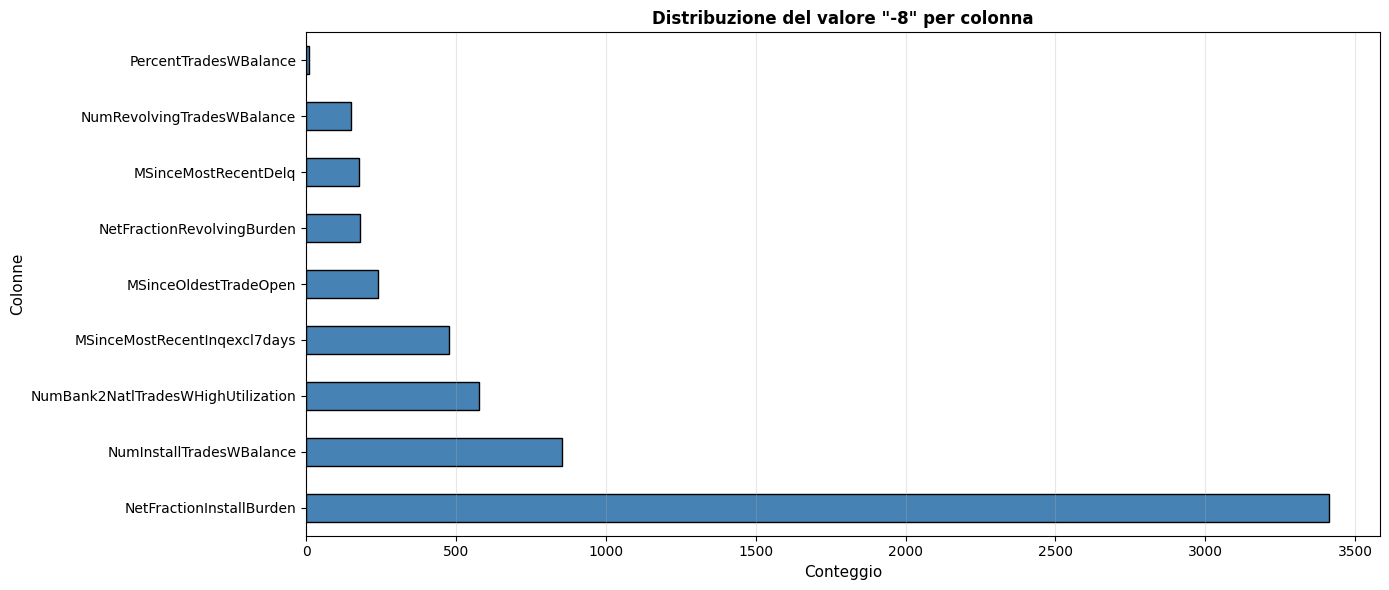

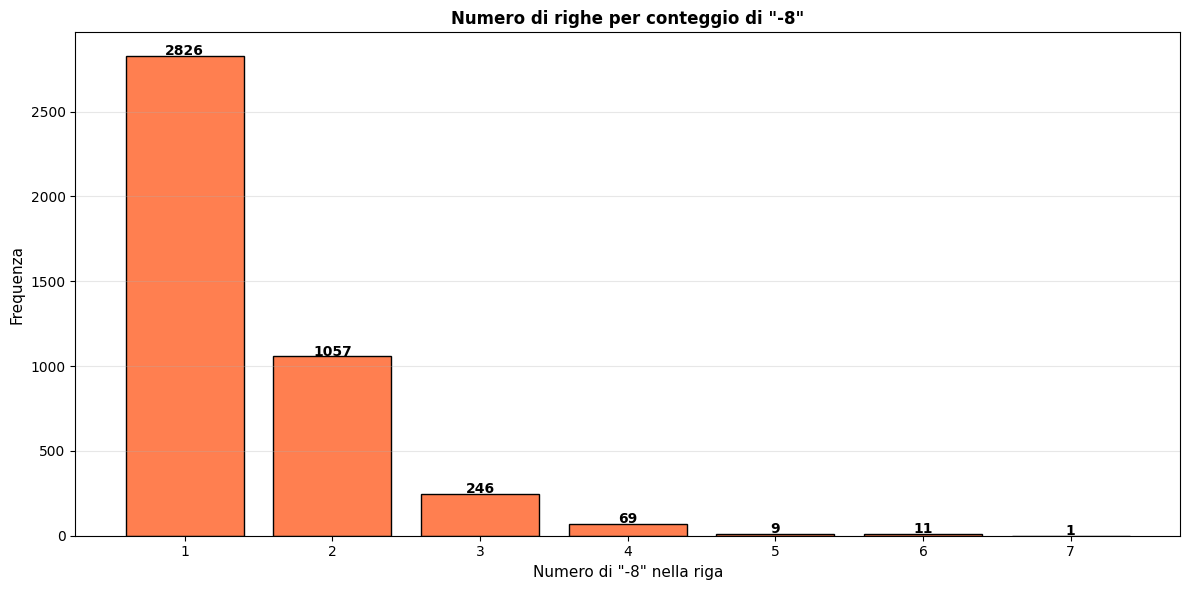

In [15]:
#Analisi del valore "-8" su heloc_dataset_no9.csv

# Caricamento del dataset senza -9
df = pd.read_csv('/Users/marco/Documents/Biometry/DLL/DLLM_Project/DLLM_Project/data/processed/heloc_dataset_no9ML.csv')

# Conteggio di -8 per colonna
minus_8_per_col = (df == -8).sum()

# Colonne che hanno almeno un -8
cols_with_minus_8 = minus_8_per_col[minus_8_per_col > 0].sort_values(ascending=False)

print(f"\nColonne con almeno un valore '-8': {len(cols_with_minus_8)}")
print("\nDistribuzione di '-8' per colonna:")
print(cols_with_minus_8)

# Righe con almeno un -8
rows_with_minus_8 = (df == -8).any(axis=1)
print(f"\n\nRighe con almeno un valore '-8': {rows_with_minus_8.sum():,}")
print(f"Percentuale del dataset: {(rows_with_minus_8.sum() / len(df) * 100):.2f}%")

# Statistiche per righe con -8
minus_8_count_per_row = (df == -8).sum(axis=1)
rows_with_any_minus_8 = minus_8_count_per_row > 0

print(f"\n\nStatistiche per righe con almeno un valore '-8':")
if rows_with_any_minus_8.any():
    print(f"  Media di '-8' per riga (escludendo zeri): {minus_8_count_per_row[rows_with_any_minus_8].mean():.2f}")
    print(f"  Minimo: {minus_8_count_per_row[rows_with_any_minus_8].min()}")
    print(f"  Massimo: {minus_8_count_per_row[rows_with_any_minus_8].max()}")
    print(f"  Mediana: {minus_8_count_per_row[rows_with_any_minus_8].median():.2f}")

# Visualizzazione: Distribuzione -8 per colonna
fig, ax = plt.subplots(figsize=(14, 6))
cols_with_minus_8.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribuzione del valore "-8" per colonna', fontsize=12, fontweight='bold')
ax.set_xlabel('Conteggio', fontsize=11)
ax.set_ylabel('Colonne', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Visualizzazione: Percentuale di righe per conteggio di -8
value_counts_8 = minus_8_count_per_row[minus_8_count_per_row > 0].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(value_counts_8.index, value_counts_8.values, color='coral', edgecolor='black')
ax.set_title('Numero di righe per conteggio di "-8"', fontsize=12, fontweight='bold')
ax.set_xlabel('Numero di "-8" nella riga', fontsize=11)
ax.set_ylabel('Frequenza', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Aggiungi i valori sopra le barre
for i, v in enumerate(value_counts_8.values):
    ax.text(value_counts_8.index[i], v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [16]:
# Caricamento dataset con -7 già gestito
df = pd.read_csv('/Users/marco/Documents/Biometry/DLL/DLLM_Project/DLLM_Project/data/processed/heloc_dataset_no9_no7ML.csv')

# Colonne con -8 e loro semantica:
# feature "mesi da evento"  -> NaN sulla numerica (stesso ragionamento del -7)
# feature "conteggio/percentuale" -> 0 sulla numerica (zero trades = zero, non valore ignoto)
cols_minus8_to_nan = [
    'MSinceOldestTradeOpen',        # mesi -> NaN
    'MSinceMostRecentDelq',         # mesi -> NaN (ha già _never da step -7)
    'MSinceMostRecentInqexcl7days', # mesi -> NaN (ha già _never da step -7)
]
cols_minus8_to_zero = [
    'NetFractionRevolvingBurden',           # percentuale -> 0
    'NetFractionInstallBurden',             # percentuale -> 0
    'NumRevolvingTradesWBalance',           # conteggio   -> 0
    'NumInstallTradesWBalance',             # conteggio   -> 0
    'NumBank2NatlTradesWHighUtilization',   # conteggio   -> 0
    'PercentTradesWBalance',                # percentuale -> 0
]

print("Prima della sostituzione — conteggio -8 per colonna:")
all_cols = cols_minus8_to_nan + cols_minus8_to_zero
for col in all_cols:
    # -8 potrebbe essere intero o stringa '-8' a causa del salvataggio precedente
    count_int = (df[col] == -8).sum() if df[col].dtype != object else 0
    count_str = (df[col] == '-8').sum() if df[col].dtype == object else 0
    total = count_int + count_str
    if total > 0:
        print(f"  {col}: {total}")

# --- Colonne "mesi": booleano _no_trades + NaN ---
for col in cols_minus8_to_nan:
    is_minus8 = (df[col] == -8) | (df[col] == '-8')
    df[f'{col}_no_trades'] = is_minus8.astype(int)
    df[col] = df[col].where(~is_minus8, other=np.nan)

# --- Colonne "conteggio/percentuale": booleano _no_trades + 0 ---
for col in cols_minus8_to_zero:
    is_minus8 = (df[col] == -8) | (df[col] == '-8')
    df[f'{col}_no_trades'] = is_minus8.astype(int)
    df[col] = df[col].where(~is_minus8, other=0)

print("\nDopo la sostituzione — verifica:")
bool_cols = [f'{col}_no_trades' for col in all_cols]
for col, bcol in zip(all_cols, bool_cols):
    n_bool = df[bcol].sum()
    n_nan  = df[col].isna().sum() if col in cols_minus8_to_nan else None
    if col in cols_minus8_to_nan:
        print(f"  {col}: {n_bool} righe con _no_trades=1 | NaN sulla numerica: {n_nan}")
    else:
        print(f"  {col}: {n_bool} righe con _no_trades=1 | 0 sulla numerica")

# Verifica nessun -8 rimasto
remaining = ((df[all_cols] == -8) | (df[all_cols] == '-8')).sum().sum()
print(f"\nVerifica: valori -8 rimasti = {remaining}")

print(f"\nShape finale: {df.shape} ({df.shape[1] - len(all_cols) - len(bool_cols)} originali + {len(all_cols)} numeriche + {len(bool_cols)} booleani)")

# Salvataggio
df.to_csv('/Users/marco/Documents/Biometry/DLL/DLLM_Project/DLLM_Project/data/processed/heloc_dataset_cleanedML.csv', index=False)

Prima della sostituzione — conteggio -8 per colonna:
  MSinceOldestTradeOpen: 239
  MSinceMostRecentDelq: 176
  MSinceMostRecentInqexcl7days: 476
  NetFractionRevolvingBurden: 179
  NetFractionInstallBurden: 3412
  NumRevolvingTradesWBalance: 149
  NumInstallTradesWBalance: 854
  NumBank2NatlTradesWHighUtilization: 576
  PercentTradesWBalance: 11

Dopo la sostituzione — verifica:
  MSinceOldestTradeOpen: 239 righe con _no_trades=1 | NaN sulla numerica: 239
  MSinceMostRecentDelq: 176 righe con _no_trades=1 | NaN sulla numerica: 4834
  MSinceMostRecentInqexcl7days: 476 righe con _no_trades=1 | NaN sulla numerica: 2329
  NetFractionRevolvingBurden: 179 righe con _no_trades=1 | 0 sulla numerica
  NetFractionInstallBurden: 3412 righe con _no_trades=1 | 0 sulla numerica
  NumRevolvingTradesWBalance: 149 righe con _no_trades=1 | 0 sulla numerica
  NumInstallTradesWBalance: 854 righe con _no_trades=1 | 0 sulla numerica
  NumBank2NatlTradesWHighUtilization: 576 righe con _no_trades=1 | 0 sulla

In [17]:
# SUMMARY - Riepilogo del Preprocessing

# Caricamento dei dataset per il confronto
df_original = pd.read_csv('/Users/marco/Documents/Biometry/DLL/DLLM_Project/DLLM_Project/data/raw/heloc_dataset.csv')
df_final = pd.read_csv('/Users/marco/Documents/Biometry/DLL/DLLM_Project/DLLM_Project/data/processed/heloc_dataset_cleanedML.csv')

print(f"\nSTATISTICHE GENERALI:")
print(f"  Dataset originale: {len(df_original):,} righe {len(df_original.columns)} colonne")
print(f"  Dataset finale: {len(df_final):,} righe  {len(df_final.columns)} colonne")
print(f"  Righe eliminate: {len(df_original) - len(df_final):,} ({((len(df_original) - len(df_final)) / len(df_original) * 100):.2f}%)")

print(f"\n SPECIAL VALUES RIMOSSI/SOSTITUITI:")
print(f"  -9: Rimossi (588 righe eliminate)")
print(f"  -7: Sostituiti (206 valori in 2 colonne)")
print(f"       • MSinceMostRecentDelq: 'Never Had Delinquency'")
print(f"       • MSinceMostRecentInqexcl7days: 'No Credit Inquiry'")
print(f"  -8: Sostituiti (11,072 valori in 9 colonne)")
print(f"       • MSinceOldestTradeOpen: 'New to Credit System'")
print(f"       • PercentTradesWBalance: 'No Valid Credit Accounts'")
print(f"       • NumRevolvingTradesWBalance: 'No Revolving Accounts'")
print(f"       • NumBank2NatlTradesWHighUtilization: 'No Bank Revolving'")
print(f"       • NetFractionRevolvingBurden: 'No Revolving Burden'")
print(f"       • NumInstallTradesWBalance: 'No Installment Loans'")
print(f"       • NetFractionInstallBurden: 'No Installment Burden'")
print(f"       • MSinceMostRecentDelq: 'No Payment History'")
print(f"       • MSinceMostRecentInqexcl7days: 'No Inquiry Record'")

# Verifica assenza special values nel dataset finale
print(f"\n VERIFICA FINALE:")
remaining_9 = (df_final == -9).sum().sum() + (df_final == "-9").sum().sum()
remaining_8 = (df_final == -8).sum().sum() + (df_final == "-8").sum().sum()
remaining_7 = (df_final == -7).sum().sum() + (df_final == "-7").sum().sum()

print(f"  Valori -9 rimasti: {remaining_9}")
print(f"  Valori -8 rimasti: {remaining_8}")
print(f"  Valori -7 rimasti: {remaining_7}")

if remaining_9 == 0 and remaining_8 == 0 and remaining_7 == 0:
    print(f"\n  Dataset completamente pulito")
else:
    print(f"\n  Attenzione: Rimangono special values nel dataset")






STATISTICHE GENERALI:
  Dataset originale: 10,459 righe 24 colonne
  Dataset finale: 9,861 righe  35 colonne
  Righe eliminate: 598 (5.72%)

 SPECIAL VALUES RIMOSSI/SOSTITUITI:
  -9: Rimossi (588 righe eliminate)
  -7: Sostituiti (206 valori in 2 colonne)
       • MSinceMostRecentDelq: 'Never Had Delinquency'
       • MSinceMostRecentInqexcl7days: 'No Credit Inquiry'
  -8: Sostituiti (11,072 valori in 9 colonne)
       • MSinceOldestTradeOpen: 'New to Credit System'
       • PercentTradesWBalance: 'No Valid Credit Accounts'
       • NumRevolvingTradesWBalance: 'No Revolving Accounts'
       • NumBank2NatlTradesWHighUtilization: 'No Bank Revolving'
       • NetFractionRevolvingBurden: 'No Revolving Burden'
       • NumInstallTradesWBalance: 'No Installment Loans'
       • NetFractionInstallBurden: 'No Installment Burden'
       • MSinceMostRecentDelq: 'No Payment History'
       • MSinceMostRecentInqexcl7days: 'No Inquiry Record'

 VERIFICA FINALE:
  Valori -9 rimasti: 0
  Valori -8 ri

In [21]:
# Creazione tabella riepilogativa del dataset
import pandas as pd

# Caricamento dataset
df_original = pd.read_csv('../data/raw/heloc_dataset.csv')
df_final = pd.read_csv('../data/processed/heloc_dataset_cleanedML.csv')

# Identificare colonne numeriche e categoriche SUL DATASET FINALE
numeric_cols = df_final.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_final.select_dtypes(include=['object']).columns.tolist()

numeric_cols_final = len(numeric_cols)
categorical_cols_final = len(categorical_cols)
total_features = numeric_cols_final + categorical_cols_final

# Righe originali vs pulite
righe_originali = len(df_original)
righe_pulite = len(df_final)
righe_eliminate = righe_originali - righe_pulite

# Creazione della tabella riepilogativa (STESSO TEMPLATE)
riepilogo_data = {
    'Dataset': ['HELOC'],
    'N. features numeriche': [numeric_cols_final],
    'N. features categoriche': [categorical_cols_final],
    'N. totale features': [total_features],
    'N. campioni originali': [righe_originali],
    'N. campioni post pulizia': [righe_pulite],
    'N. righe eliminate': [righe_eliminate]
}

df_riepilogo = pd.DataFrame(riepilogo_data)
# Salvataggio
df_riepilogo.to_csv('../data/processed/riepilogo_datasetML.csv', index=False)


/var/folders/8g/3_yjjvpn7113xq7pfkgkcbzr0000gn/T/ipykernel_75078/4169368474.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_final.select_dtypes(include=['object']).columns.tolist()
